# Intro

## Introduction. Write your answers in the Intro section of your notebook

1. Посчитать ожидаемую цену на квартиру, понять болен ли человек по его симптомам, понять способен ли человек отдать кредит, выяснить какому клиенту больше подходит тот или иной продукт, найти банан. Преимущество в том, что мы автоматизируем процесс и вычисляем быстрее
2. регрессия, классификация, классификация, генерализация, классификация
3. multiclass - один обьект принадлежит одному классу, но классов большу двух. multilabel обьект может принадлежать нескольким классам одновременно
4. регрессия. регрессию можно сделать классификацией

## Introduction to Data Analysis

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm
import scipy
import statsmodels
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_json('data/train.json')
train

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124000,1.0,3,92bbbf38baadfde0576fc496bd41749c,2016-04-05 03:58:33,There is 700 square feet of recently renovated...,W 171 Street,"[Elevator, Dishwasher, Hardwood Floors]",40.8433,6824800,-73.9396,a61e21da3ba18c7a3d54cfdcc247e1f8,[https://photos.renthop.com/2/6824800_0682be16...,2800,620 W 171 Street,low
124002,1.0,2,5565db9b7cba3603834c4aa6f2950960,2016-04-02 02:25:31,"2 bedroom apartment with updated kitchen, rece...",Broadway,"[Common Outdoor Space, Cats Allowed, Dogs Allo...",40.8198,6813268,-73.9578,8f90e5e10e8a2d7cf997f016d89230eb,[https://photos.renthop.com/2/6813268_1e6fcc32...,2395,3333 Broadway,medium
124004,1.0,1,67997a128056ee1ed7d046bbb856e3c7,2016-04-26 05:42:03,No Brokers Fee * Never Lived 1 Bedroom 1 Bathr...,210 Brighton 15th St,"[Dining Room, Elevator, Pre-War, Laundry in Bu...",40.5765,6927093,-73.9554,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/6927093_93a52104...,1850,210 Brighton 15th St,medium
124008,1.0,2,3c0574a740154806c18bdf1fddd3d966,2016-04-19 02:47:33,Wonderful Bright Chelsea 2 Bedroom apartment o...,West 21st Street,"[Pre-War, Laundry in Unit, Dishwasher, No Fee,...",40.7448,6892816,-74.0017,c3cd45f4381ac371507090e9ffabea80,[https://photos.renthop.com/2/6892816_1a8d087a...,4195,350 West 21st Street,medium


#### The size is 49352 * 15

In [3]:
print(train.columns)

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')


#### The target is price

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  object 
 3   created          49352 non-null  object 
 4   description      49352 non-null  object 
 5   display_address  49352 non-null  object 
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  object 
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  object 
 14  interest_level   49352 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 6.0+ MB


In [5]:
train.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


In [6]:
train.corr(numeric_only=True)

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


#### There are no empty columns.

In [7]:
df = train[['bathrooms', 'bedrooms', 'interest_level', 'price']]
df

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


## Statistical Data Analysis

### Target analysis

In [8]:
df['price'].quantile(0.99)

np.float64(13000.0)

Text(0.5, 1.0, 'Histplot')

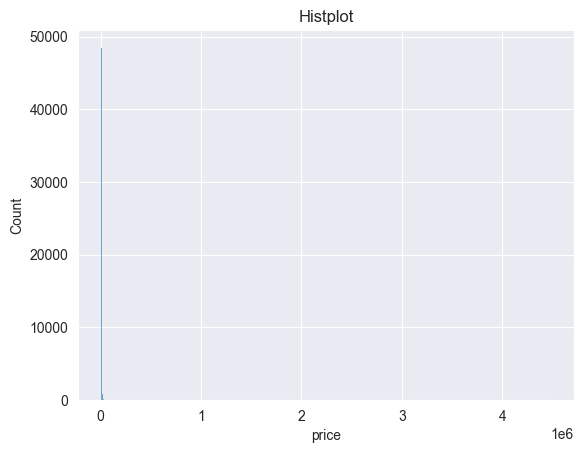

In [9]:
sns.histplot(data=df, x='price')
plt.title('Histplot')

Text(0.5, 1.0, 'Boxplot')

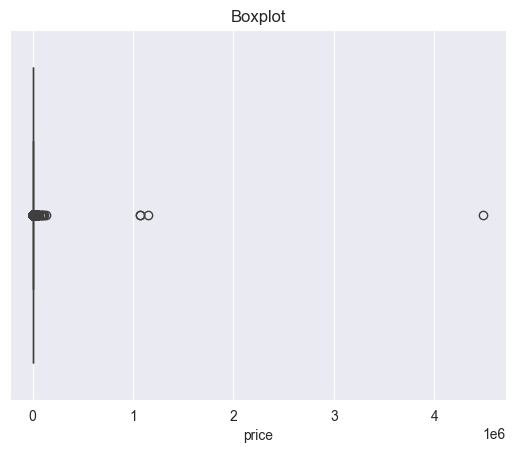

In [10]:
sns.boxplot(data=df, x='price')
plt.title('Boxplot')

выбросы есть

In [11]:
low = df['price'].quantile(0.01)
high = df['price'].quantile(0.99)
df = df.copy()[(df['price'].copy() > low) & (df['price'].copy() < high)]
df

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795
...,...,...,...,...
124000,1.0,3,low,2800
124002,1.0,2,medium,2395
124004,1.0,1,medium,1850
124008,1.0,2,medium,4195


Text(0.5, 1.0, 'Histplot after removing outliers')

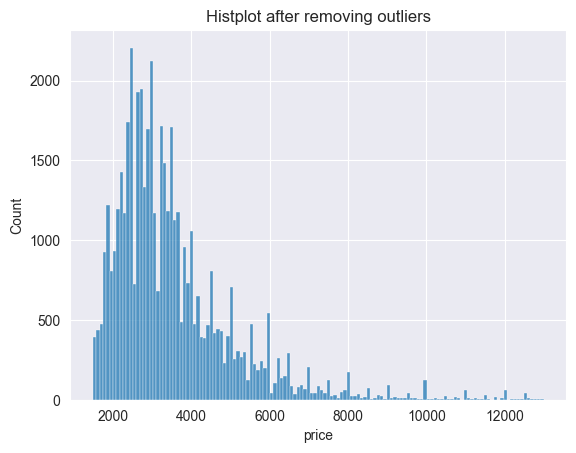

In [12]:
sns.histplot(data=df, x='price')
plt.title('Histplot after removing outliers')

терь выбросов нет

### Characteristics Analysis

In [13]:
df['interest_level'].dtype

dtype('O')

In [14]:
print(df['interest_level'])
df['interest_level'].unique()

4         medium
6            low
9         medium
10        medium
15           low
           ...  
124000       low
124002    medium
124004    medium
124008    medium
124009      high
Name: interest_level, Length: 48343, dtype: object


array(['medium', 'low', 'high'], dtype=object)

In [15]:
df.loc[:, 'interest_level'] = df.loc[:, 'interest_level'].apply(lambda x: 0 if x == 'low' else (1 if x == 'medium' else 2))
df['interest_level']

4         1
6         0
9         1
10        1
15        0
         ..
124000    0
124002    1
124004    1
124008    1
124009    2
Name: interest_level, Length: 48343, dtype: object

Text(0.5, 1.0, 'bathrooms Distribution')

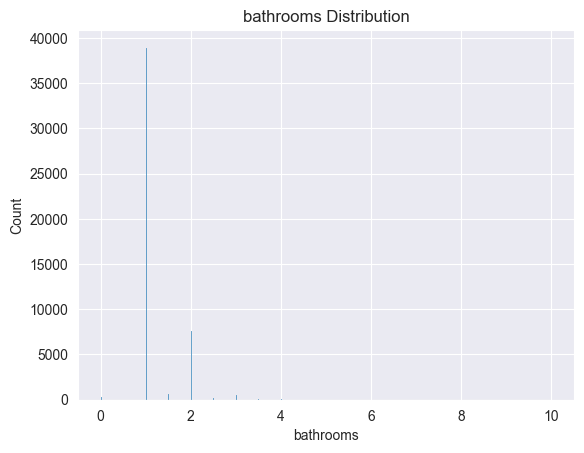

In [16]:
sns.histplot(data=df, x='bathrooms')
plt.title('bathrooms Distribution')

Text(0.5, 1.0, 'bedrooms Distribution')

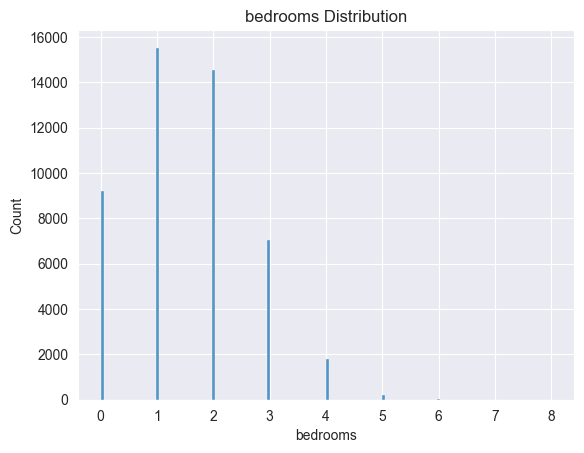

In [17]:
sns.histplot(data=df, x='bedrooms')
plt.title('bedrooms Distribution')

no outliers

### Complex analysis

In [18]:
corr_matrix = df.corr()
corr_matrix

,bathrooms,bedrooms,interest_level,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest_level,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


Text(0.5, 1.0, 'correlation matrix')

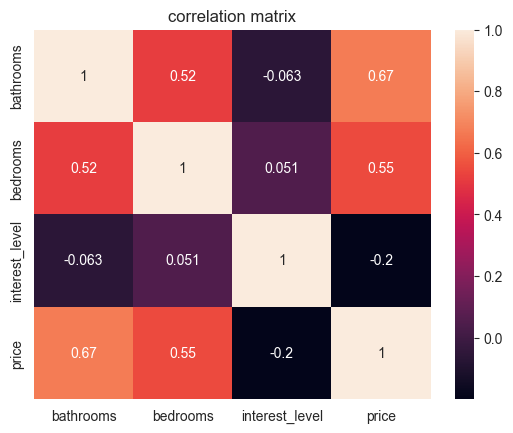

In [19]:
sns.heatmap(data=corr_matrix, annot=True)
plt.title('correlation matrix')

Text(0.5, 1.0, 'price to bedrooms')

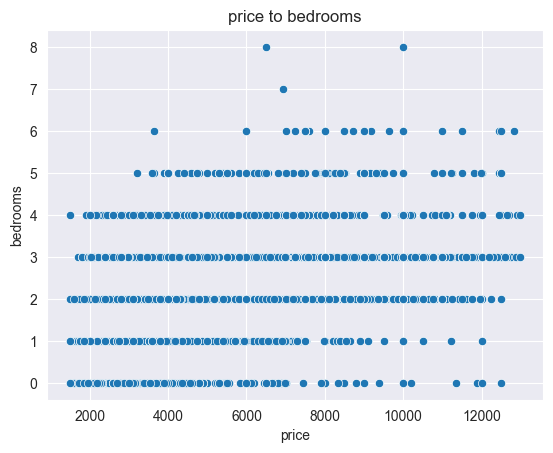

In [20]:
sns.scatterplot(data=df, x='price', y='bedrooms')
plt.title('price to bedrooms')

Text(0.5, 1.0, 'price to bathrooms')

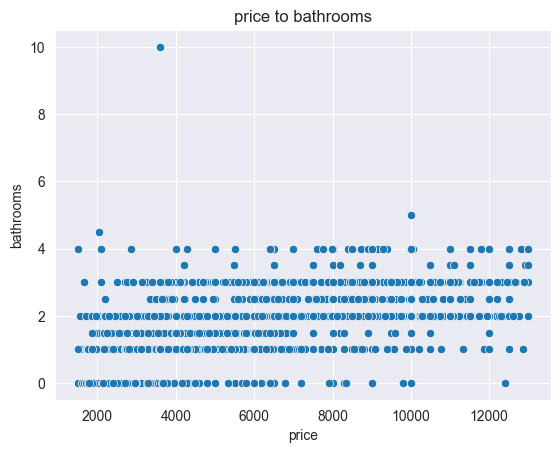

In [21]:
sns.scatterplot(data=df, x='price', y='bathrooms')
plt.title('price to bathrooms')

Text(0.5, 1.0, 'price to interest_level')

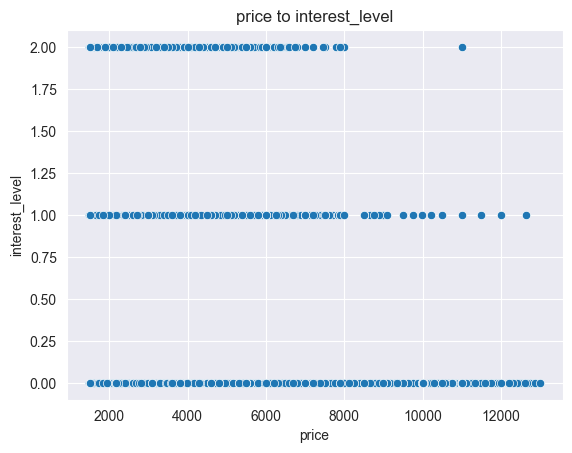

In [22]:
sns.scatterplot(data=df, x='price', y='interest_level')
plt.title('price to interest_level')

## Creating Features

In [23]:
bathrooms_squared = df['bathrooms']**2
bedrooms_squared = df['bedrooms']**2
interest_level_squared = df['interest_level']**2
df['bathrooms_squared'] = bathrooms_squared
df['bedrooms_squared'] = bedrooms_squared
df['interest_level_squared'] = interest_level_squared
df

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
4,1.0,1,1,2400,1.00,1,1
6,1.0,2,0,3800,1.00,4,0
9,1.0,2,1,3495,1.00,4,1
10,1.5,3,1,3000,2.25,9,1
15,1.0,0,0,2795,1.00,0,0
...,...,...,...,...,...,...,...
124000,1.0,3,0,2800,1.00,9,0
124002,1.0,2,1,2395,1.00,4,1
124004,1.0,1,1,1850,1.00,1,1
124008,1.0,2,1,4195,1.00,4,1


Text(0.5, 1.0, 'corr_matrix with squared values')

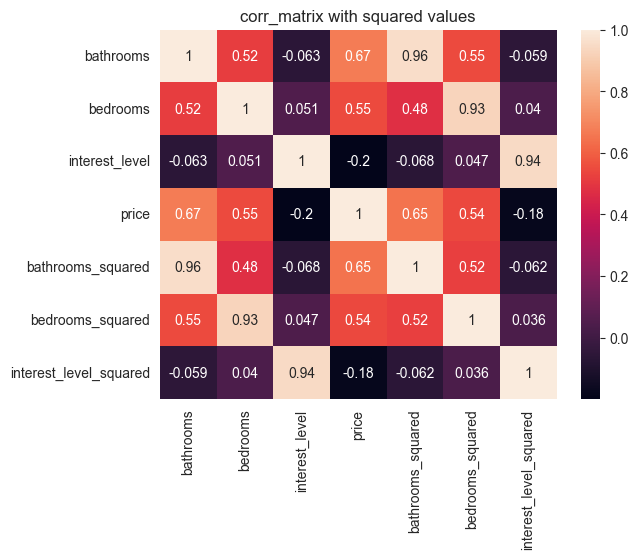

In [24]:
new_corr_matrix = df.corr()
sns.heatmap(data=new_corr_matrix, annot=True)
plt.title('corr_matrix with squared values')

No, new features are not more correlated

In [25]:
df = df.drop(columns=['bathrooms_squared', 'bedrooms_squared', 'interest_level_squared'])
X = df.drop(columns=['price'])
y = df['price']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [27]:
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit(X_train)

X_train_poly = poly.transform(X_train)
X_test_poly = poly.transform(X_test)

## Now you need to train 3 models: linear regression, decision tree and naive model. We will use them as black boxes without deep understanding.

In [28]:
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])

### Linear Regression

In [29]:
linreg = LinearRegression()
linreg.fit(X_train_poly, y_train)
predict_train = linreg.predict(X_train_poly)
predict_test = linreg.predict(X_test_poly)

In [30]:
MAE_train_logreg = mean_absolute_error(y_train, predict_train)
MAE_test_logreg = mean_absolute_error(y_test, predict_test)
RMSE_train_logreg = np.sqrt(mean_squared_error(y_train, predict_train))
RMSE_test_logreg = np.sqrt(mean_squared_error(y_test, predict_test))
result_MAE.loc[0] = ['Linear Regression', MAE_train_logreg, MAE_test_logreg]
result_RMSE.loc[0] = ['Linear Regression', RMSE_train_logreg, RMSE_test_logreg]
result_RMSE

,model,train,test
0,Linear Regression,1025.592951,51089.579289


### Decision Tree


In [31]:
tree = DecisionTreeRegressor(random_state=21)
tree.fit(X_train_poly, y_train)
tree_predict_train = tree.predict(X_train_poly)
tree_predict_test = tree.predict(X_test_poly)

In [32]:
MAE_train_tree = mean_absolute_error(y_train, tree_predict_train)
MAE_test_tree = mean_absolute_error(y_test, tree_predict_test)
RMSE_train_tree = np.sqrt(mean_squared_error(y_train, tree_predict_train))
RMSE_test_tree = np.sqrt(mean_squared_error(y_test, tree_predict_test))
result_MAE.loc[1] = ['Decision Tree', MAE_train_tree, MAE_test_tree]
result_RMSE.loc[1] = ['Decision Tree', RMSE_train_tree, RMSE_test_tree]
result_RMSE

,model,train,test
0,Linear Regression,1025.592951,51089.579289
1,Decision Tree,1025.483464,1032.541333


### Naive Models

In [33]:
price_mean_train = np.full_like(y_train, y_train.mean())
price_mean_test = np.full_like(y_test, y_test.mean())
price_median_train = np.full_like(y_train, y_train.median())
price_median_test = np.full_like(y_test, y_test.median())

In [34]:
MAE_mean_train = mean_absolute_error(y_train, price_mean_train)
MAE_mean_test = mean_absolute_error(y_test, price_mean_test)
MAE_median_train = mean_absolute_error(y_train, price_median_train)
MAE_median_test = mean_absolute_error(y_test, price_median_test)
RMSE_mean_train = np.sqrt(mean_squared_error(y_train, price_mean_train))
RMSE_mean_test = np.sqrt(mean_squared_error(y_test, price_mean_test))
RMSE_median_train = np.sqrt(mean_squared_error(y_train, price_median_train))
RMSE_median_test = np.sqrt(mean_squared_error(y_test, price_median_test))

In [35]:
result_MAE.loc[2] = ['naive_mean', MAE_mean_train, MAE_mean_test]
result_MAE.loc[3] = ['naive_median', MAE_median_train, MAE_median_test]
result_RMSE.loc[2] = ['naive_mean', RMSE_mean_train, RMSE_mean_test]
result_RMSE.loc[3] = ['naive_median', RMSE_median_train, RMSE_median_test]

In [36]:
result_MAE

,model,train,test
0,Linear Regression,718.833479,1249.726572
1,Decision Tree,718.825041,727.070811
2,naive_mean,1131.595620,1144.387010
3,naive_median,1079.734162,1092.166408


In [37]:
result_RMSE

,model,train,test
0,Linear Regression,1025.592951,51089.579289
1,Decision Tree,1025.483464,1032.541333
2,naive_mean,1580.460891,1606.034116
3,naive_median,1626.873056,1651.661962


Tree is the best model